In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data.pkl
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/version
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/byteorder
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/.data/serialization_id
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data/437
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data/248
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data/7
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data/135
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data/47
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data/183
/kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best/data/313
/kaggle/input/datasets/shashwatkumarjha/wei

In [2]:
!pip install ultralytics
!pip install boxmot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 50.4 MB/s eta 0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=7922843266b6985b67aede416211a58537a364640cfa9ea349e6e71a073ab5dd
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy
  Attempting uninstall: regex
    Found 

In [3]:
import os
import shutil

# 1. Scan for the folder containing the 'version' file
target_folder = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'version' in files and 'data.pkl' in files:
        target_folder = root
        break

if target_folder:
    # Separate the parent path from the folder name
    parent_dir = os.path.dirname(target_folder)
    base_dir = os.path.basename(target_folder)
    
    print(f"✅ Found the model folder at: {target_folder}")
    
    # 2. CRUCIAL FIX: Zip it while preserving the base_dir folder structure!
    archive_path = '/kaggle/working/best_repacked'
    shutil.make_archive(archive_path, 'zip', root_dir=parent_dir, base_dir=base_dir)
    
    # 3. Rename to .pt
    final_pt_path = '/kaggle/working/best.pt'
    if os.path.exists(final_pt_path):
        os.remove(final_pt_path)
    os.rename(archive_path + '.zip', final_pt_path)
    
    print(f"🚀 Model successfully repacked! Ready to use at: {final_pt_path}")
else:
    print("❌ Could not find the model files.")

✅ Found the model folder at: /kaggle/input/datasets/shashwatkumarjha/weightsfinal/best (2) newest.pt/best
🚀 Model successfully repacked! Ready to use at: /kaggle/working/best.pt


In [4]:
import os
import cv2
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from boxmot import BotSort

# Disable W&B logging if you don't use it
os.environ['WANDB_DISABLED'] = 'true'

def create_video_writer(video_cap, output_filename):
    # Grab the width, height, and fps of the frames in the video stream.
    frame_width = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(video_cap.get(cv2.CAP_PROP_FPS))

    # Initialize the FourCC and a video writer object
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    writer = cv2.VideoWriter(output_filename, fourcc, fps, (frame_width, frame_height))

    return writer

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import cv2
import numpy as np
import torch
import gc # Crucial for memory management
from pathlib import Path
from ultralytics import YOLO
from boxmot import BotSort
from collections import deque
import os

os.environ['WANDB_DISABLED'] = 'true'

# Initialize the tracker
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
tracker = BotSort(
    reid_weights=Path('osnet_x0_25_msmt17.pt'),  # which ReID model to use
    device=device,
    half=False
)

# Initialize YOLO
yolo_model = YOLO('/kaggle/working/best.pt')

# Double-check this path! Kaggle folders are often completely lowercase (e.g., /trimfin/)
input_video_path = '/kaggle/input/datasets/shashwatkumarjha/trimfin/DSC_0175 - Trim.mp4'
vid = cv2.VideoCapture(input_video_path)

# FIX 1: Raise an error instead of killing the kernel!
if not vid.isOpened():
    raise FileNotFoundError(f"🚨 Could not open video at {input_video_path}. Check the DATASETS panel to see if the folder name is lowercase!")

output_video_path = '/kaggle/working/videoplayback_tracked.mp4'
# Assuming create_video_writer is defined in a previous cell
out = create_video_writer(vid, output_video_path)

frame_count = 1000
counter = 0

trail_path = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}, 5:{}, 6:{}, 7:{}, 8:{}, 9:{}, 10:{}, 'fc':[]}
counter_arr = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}, 5:{}, 6:{}, 7:{}, 8:{}, 9:{}, 10:{}}

while frame_count > 0:
    counter += 1
    frame_count -= 1
    ret, im = vid.read()
    if not ret:
        trail_path['fc'].append(1000 - frame_count)
        break

    try:
        # FIX 2: Downscale frame size so it doesn't crash the GPU memory
        results = yolo_model(im, imgsz=640)

        # Convert the detections: N X (x, y, x, y, conf, cls)
        dets = []
        for result in results:
            for detection in result.boxes.data.cpu().numpy():
                x1, y1, x2, y2, conf, cls = detection
                dets.append([x1, y1, x2, y2, conf, int(cls)])
        dets = np.array(dets)

        # Update tracker with detections
        tracker.update(dets, im)
        for a in tracker.active_tracks:
            if a.history_observations.maxlen == 50:
                a.history_observations = deque(a.history_observations, maxlen=1000)

        tracker.plot_results(im, show_trajectories=True)

        # Record trail history
        for a in tracker.active_tracks:
            if len(a.history_observations) > 2:
                trail_path[a.cls][a.id] = a.history_observations
                
                if counter not in counter_arr[a.cls].get(a.id, []):
                    if a.id not in counter_arr[a.cls]:
                        counter_arr[a.cls][a.id] = []
                    counter_arr[a.cls][a.id].append(counter)

        # Write frame to video
        out.write(im)

        # FIX 3: Empty the trash!
        del results
        del dets
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"An error occurred: {e}")
        break

vid.release()
out.release()
cv2.destroyAllWindows()

print(f"Tracking video saved to {output_video_path}")

SUCCESS  | BotSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, track_high_thresh=0.5, track_low_thresh=0.1, new_track_thresh=0.6, track_buffer=30, match_thresh=0.8, proximity_thresh=0.5, appearance_thresh=0.25, cmc_method=ecc, frame_rate=30, fuse_first_associate=False, with_reid=True
INFO     | BoxMOT v16.0.10 🚀 Python-3.12.12 torch-2.9.0+cu126
CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
INFO     | osnet_x0_25_msmt17.pt
INFO     | [PID 24] Downloading ReID weights from https://drive.google.com/uc?id=1sSwXSUlj4_tHZequ_iZ8w_Jh0VaRQMqF → osnet_x0_25_msmt17.pt
Downloading...
From: https://drive.google.com/uc?id=1sSwXSUlj4_tHZequ_iZ8w_Jh0VaRQMqF
To: /kaggle/working/osnet_x0_25_msmt17.pt
100%|██████████| 3.06M/3.06M [00:00<00:00, 194MB/s]
SUCCESS  | Loaded pretrained weights from osnet_x0_25_msmt17.pt
OpenCV: FFMPEG: tag 0x44495658/'XVID' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback 


0: 384x640 11 cars, 4 2wheelers, 100.1ms
Speed: 8.8ms preprocess, 100.1ms inference, 29.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 2 2wheelers, 13.3ms
Speed: 2.3ms preprocess, 13.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 cars, 1 person, 2 2wheelers, 13.2ms
Speed: 2.3ms preprocess, 13.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 cars, 3 2wheelers, 13.1ms
Speed: 3.2ms preprocess, 13.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 1 person, 2 2wheelers, 13.2ms
Speed: 2.8ms preprocess, 13.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 cars, 1 person, 3 2wheelers, 14.6ms
Speed: 2.9ms preprocess, 14.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 cars, 2 persons, 3 2wheelers, 13.2ms
Speed: 2.6ms preprocess, 13.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384

In [6]:
import copy

def path_process(trail_path_dict):
    # Safely remove the frame count array
    fc = trail_path_dict.pop('fc', [])
    trail_path_cent_x = copy.deepcopy(trail_path_dict)
    trail_path_cent_y = copy.deepcopy(trail_path_dict)
    
    for cls in trail_path_dict.keys():
        if cls == 'fc':
            continue
        for k in trail_path_dict[cls].keys():
            for i in range(len(trail_path_dict[cls][k])):
                # Calculate center points: (x1 + x2)/2 and (y1 + y2)/2
                trail_path_cent_x[cls][k][i] = (trail_path_dict[cls][k][i][0] + trail_path_dict[cls][k][i][2]) / 2
                trail_path_cent_y[cls][k][i] = (trail_path_dict[cls][k][i][1] + trail_path_dict[cls][k][i][3]) / 2

    return trail_path_cent_x, trail_path_cent_y, fc

# Copy the data so we don't mess up the original, then process it
trail_path_2 = copy.deepcopy(trail_path)
x, y, fc = path_process(trail_path_2)

print("✅ Trajectories processed successfully!")

✅ Trajectories processed successfully!


/tmp/ipykernel_24/988139364.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


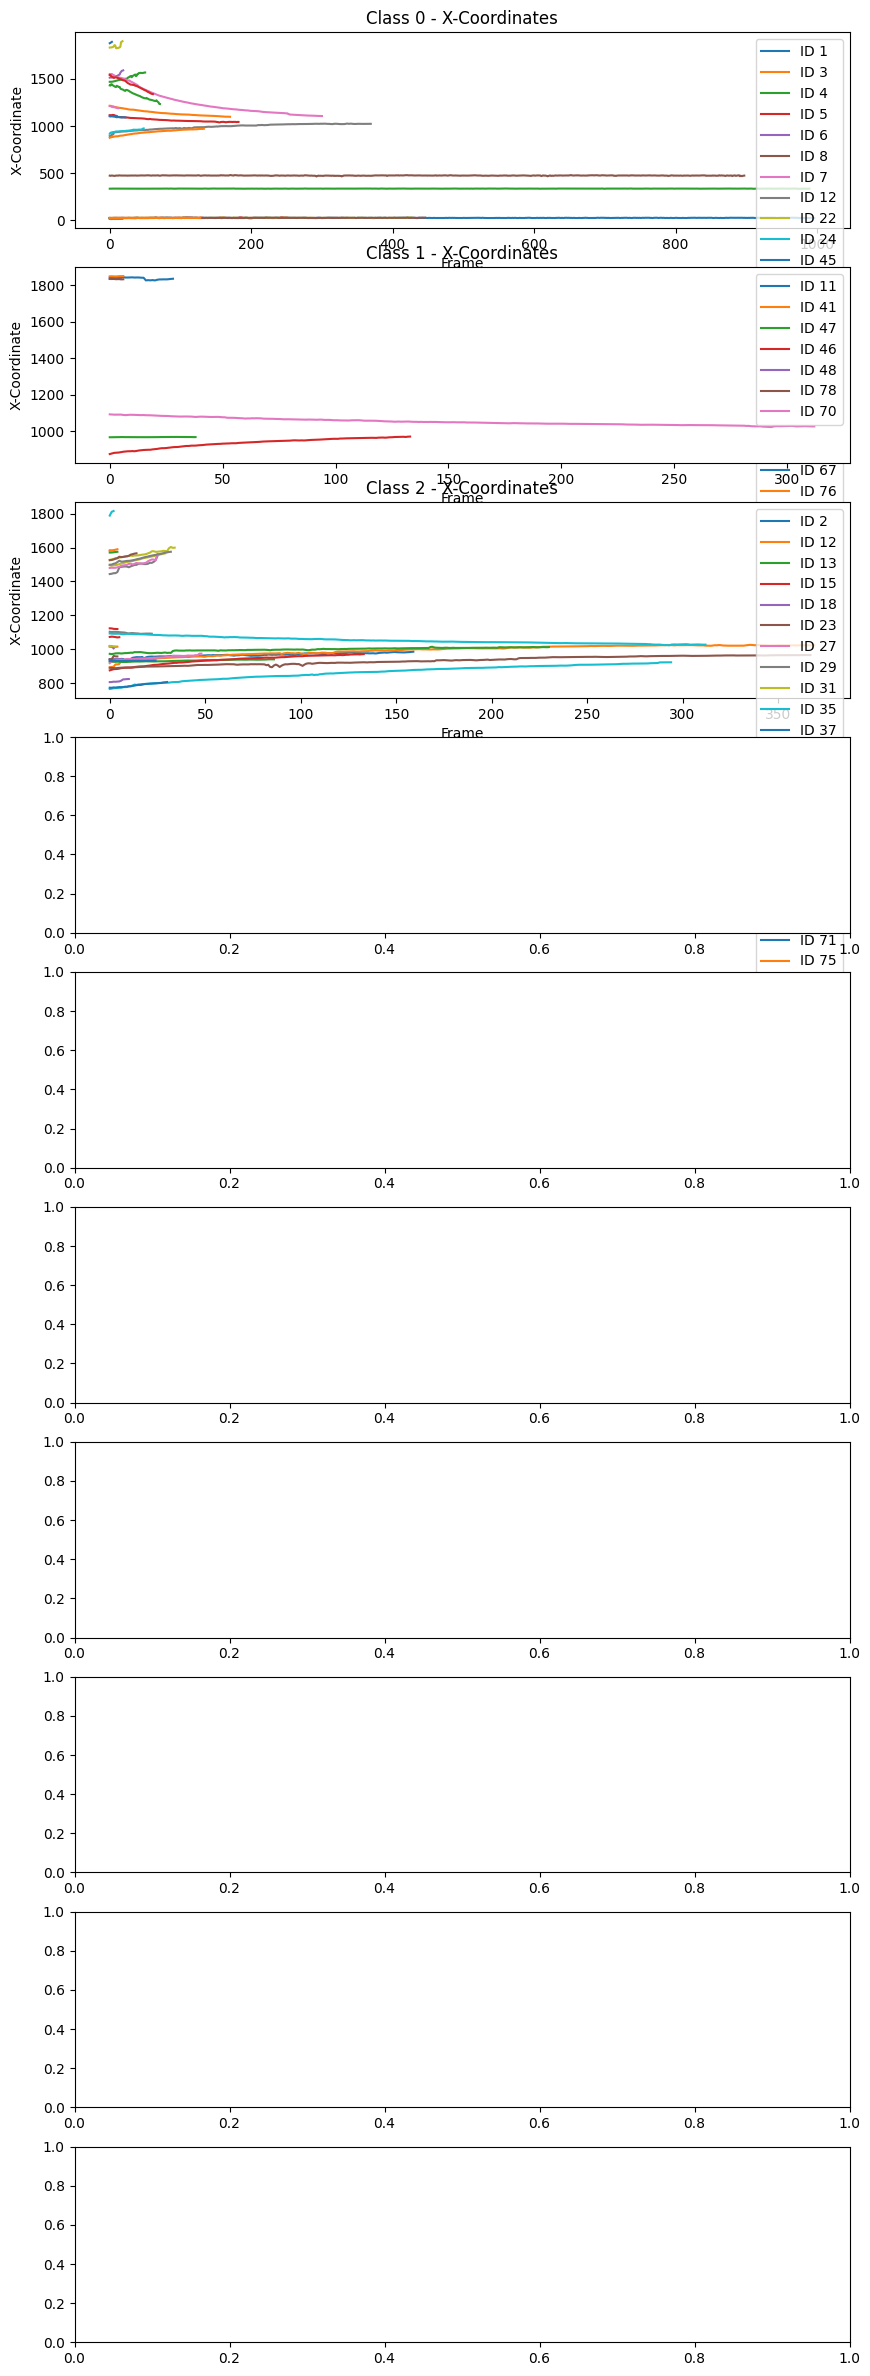

/tmp/ipykernel_24/988139364.py:28: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


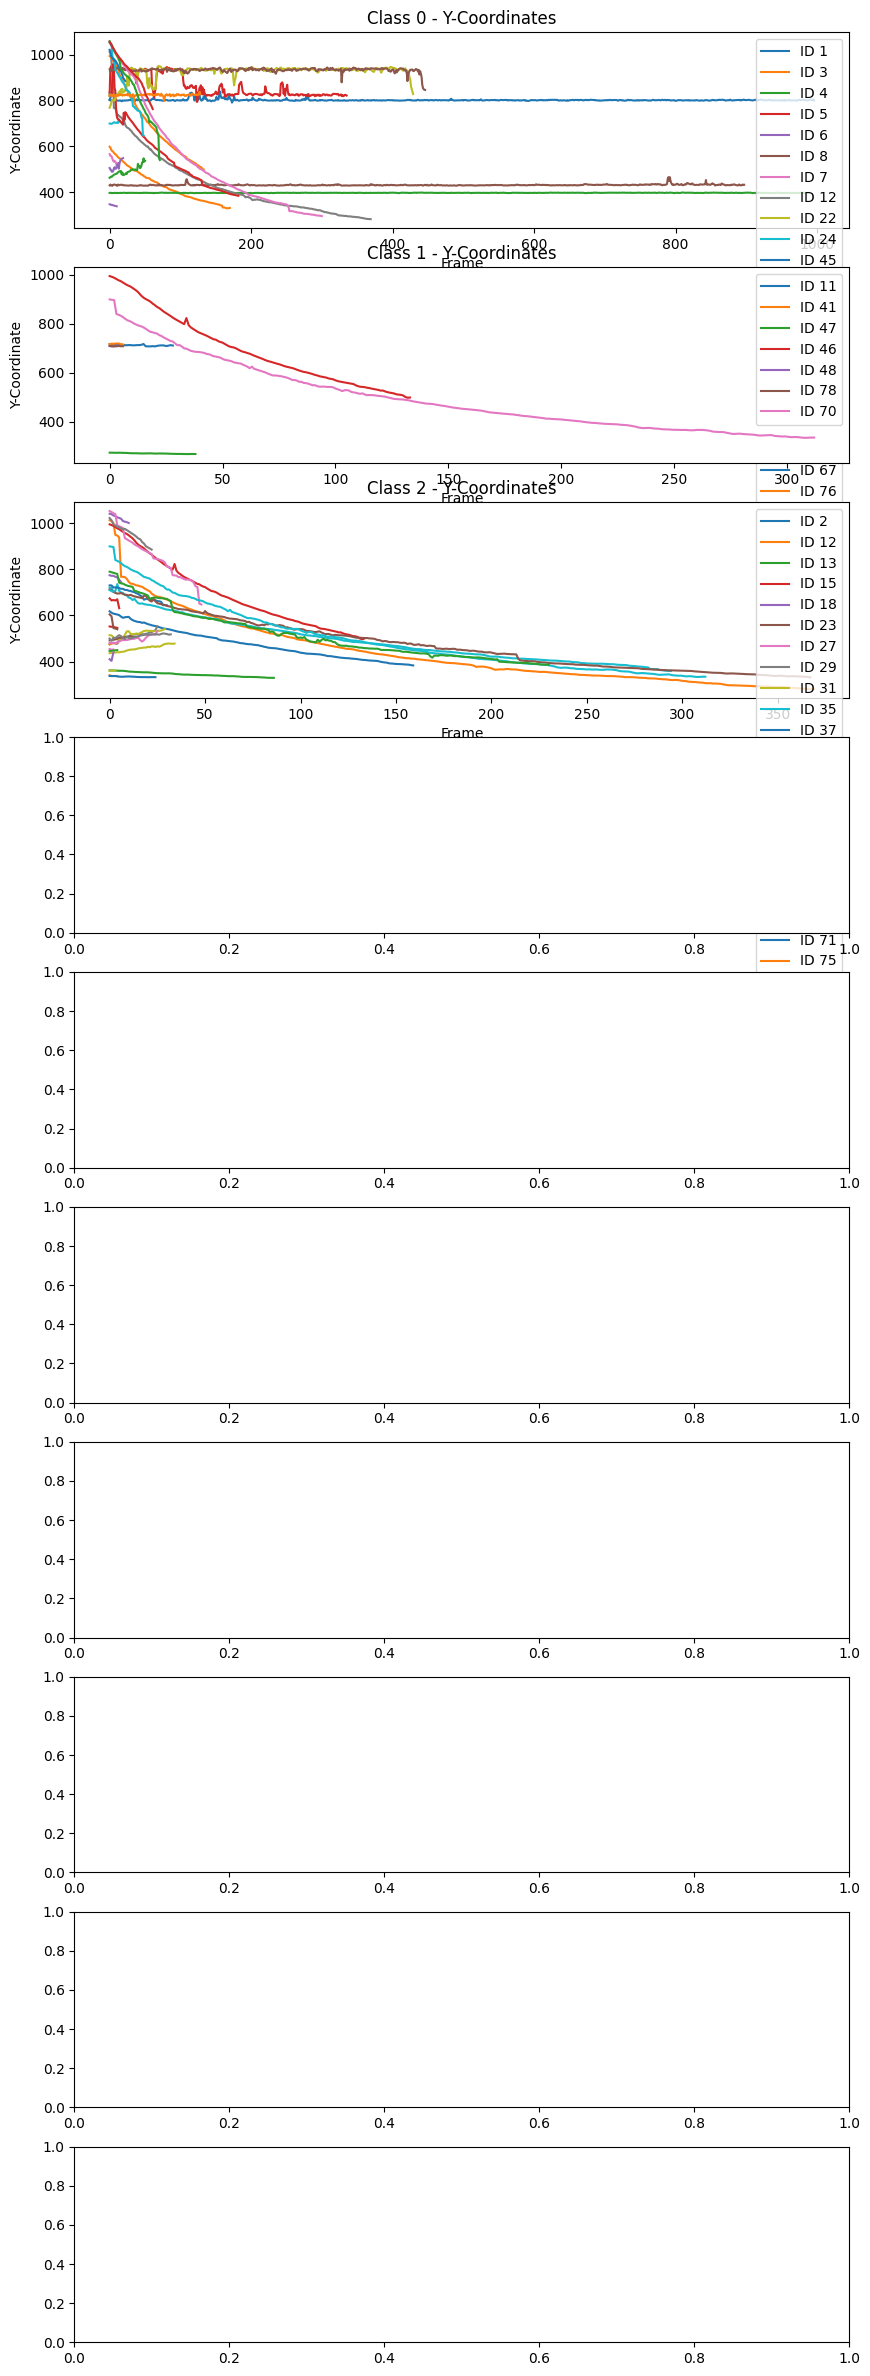

In [7]:
import matplotlib.pyplot as plt

# Plot X-Coordinates
fig_x, axes_x = plt.subplots(10, 1, figsize=(10, 30))
for cls in range(10):
    ax = axes_x[cls]
    if cls in x.keys() and x[cls]:
        for object_id in x[cls].keys():
            ax.plot(range(len(x[cls][object_id])), x[cls][object_id], label=f'ID {object_id}')
        ax.set_title(f'Class {cls} - X-Coordinates')
        ax.set_xlabel('Frame')
        ax.set_ylabel('X-Coordinate')
        ax.legend()
plt.tight_layout()
plt.show()

# Plot Y-Coordinates
fig_y, axes_y = plt.subplots(10, 1, figsize=(10, 30))
for cls in range(10):
    ax = axes_y[cls]
    if cls in y.keys() and y[cls]:
        for object_id in y[cls].keys():
            ax.plot(range(len(y[cls][object_id])), y[cls][object_id], label=f'ID {object_id}')
        ax.set_title(f'Class {cls} - Y-Coordinates')
        ax.set_xlabel('Frame')
        ax.set_ylabel('Y-Coordinate')
        ax.legend()
plt.tight_layout()
plt.show()

In [8]:
import os

output_dir = '/kaggle/working/'

for cls in range(10):
    output_filename = os.path.join(output_dir, f'output_class_{cls}.txt')

    # If class exists in x and y dictionaries
    if cls in x.keys() and cls in y.keys() and x[cls]:
         for object_id in x[cls].keys():
             if object_id in y[cls].keys():
                with open(output_filename, 'a') as file:
                    # Writing the X array, Y array, ID, and Frame Counter array
                    file.write(f"{x[cls][object_id]} {y[cls][object_id]} {object_id} {counter_arr[cls][object_id]}\n")

print("✅ Text files saved successfully to /kaggle/working/")

✅ Text files saved successfully to /kaggle/working/
